<a href="https://colab.research.google.com/github/vdlucas-queiroz/CadImobi/blob/main/COTIA_prompt_coord_geografico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# RECONSTRUÇÃO DE GEOMETRIA DE MEMORIAL DESCRITIVO POR MEIO DE COORDENADAS
# Vinicius D'Lucas Bezerra e Queiroz

In [ ]:
!pip install adjustText
!pip install simplekml
!pip install folium pyproj
!pip cache purge
!pip install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for simplekml: filename=simplekml-1.3.6-py3-none-any.whl size=65939 sha256=4860f54d5db1fd4b3a9eff37e612ce90f64dcb70226b1d79e38462f7ac8413ef
  Stored in directory: /root/.cache/pip/wheels/fd/2a/d1/84a7abdbb59566c442beb1b4fb946fe1e26c5a48fd1d5e0763
Successfully built simplekml
Files removed: 11
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 17.2 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.49.0
    Uninstalling google-auth-2.49.0:
      Successfully uninstalled google-auth-2.49.0
  Attempting uninstall: google-genai
    Found existing installation: google-genai 2.12.1
    Uninstalling google-genai-2.12.1:
      Successfully uninstall

In [ ]:
import pandas as pd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from adjustText import adjust_text
import folium
from pyproj import Transformer

from google.colab import files
from google import genai
from google.colab import userdata
import re
import time
import json

In [ ]:
# 1. Configuração da API
try:
    api_key = userdata.get('GEMINI_API_KEY')
    client = genai.Client(api_key=api_key)
    print("API Configurada com sucesso!")
except Exception as e:
    print("ERRO: Configure o Secret 'GEMINI_API_KEY' no menu lateral.")

def obter_tabela_via_ai(caminho_arquivo, prompt):
    """
    Envia o arquivo (PDF ou Imagem) diretamente para o Gemini.
    A IA faz o OCR (leitura de imagem) e a extração dos dados em um único passo.
    """

    # Busca o nome correto do modelo disponívelA
    nome_modelo = 'gemini-2.5-flash' # Versão estável e rápida

    # 2. Upload do arquivo para a API do Google (suporta PDF e Imagens)
    print(f"Fazendo upload do arquivo: {caminho_arquivo}...")
    sample_file = client.files.upload(file=caminho_arquivo)

    # Aguarda o processamento do arquivo pelo Google
    while sample_file.state.name == "PROCESSING":
        print(".", end="")
        time.sleep(2)
        sample_file = client.files.get(name=sample_file.name)

    # 3. Prompt especializado (ajustado para ler páginas 3 a 7) #AJUSTAR O PROMPT

    print("Gemini analisando o documento (OCR + Extração)...")
    response = client.models.generate_content(
        model=nome_modelo,
        contents=[sample_file, prompt],
        config={
            "response_mime_type": "application/json"
        }
    )

  # 4. Limpeza (opcional, mas boa prática)
    client.files.delete(name=sample_file.name)

    return response.text

API Configurada com sucesso!


In [ ]:
# Funções

# Conversão de gms para decimal

def gms_to_decimal(az):
    g, rest = az.split("°")
    m, s = rest.replace('"','').split("'")
    return float(g) + float(m)/60 + float(s)/3600


# Teste de rotação de coordenadas

def rotate_coords(coords, theta, pivot):
    coords = np.array(coords, dtype=float)
    x0, y0 = pivot

    translated = coords - np.array([x0, y0])

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    rotated = translated @ R.T
    return rotated + np.array([x0, y0])

  # PLOTAGEM OS RESULTADOS COM MAPA BASE

def plot_vertices_folium(
    coords,
    epsg_utm="EPSG:31983",
    zoom_start=18
):
    """
    Plota vértices e polígono em um mapa Folium.
    """

    from pyproj import Transformer
    import folium

    # Transformador UTM -> WGS84
    transformer = Transformer.from_crs(
        epsg_utm,
        "EPSG:4326",
        always_xy=True
    )

    # Conversão das coordenadas
    coords_geo = [transformer.transform(x, y) for x, y in coords]

    # Centro do mapa
    lon_c = sum(pt[0] for pt in coords_geo) / len(coords_geo)
    lat_c = sum(pt[1] for pt in coords_geo) / len(coords_geo)

    m = folium.Map(
        location=[lat_c, lon_c],
        zoom_start=zoom_start,
        tiles="OpenStreetMap"
    )

    # Polígono (AMARELO)
    folium.Polygon(
        locations=[(lat, lon) for lon, lat in coords_geo],
        color="yellow",
        weight=2,
        fill=True,
        fill_color="yellow",
        fill_opacity=0.3,
        tooltip="Polígono reconstruído"
    ).add_to(m)

    # Vértices (PONTOS BRANCOS)
    for i, ((x, y), (lon, lat)) in enumerate(zip(coords, coords_geo)):
        nome = f"P{i+1:02d}"

        # Destaque do ponto inicial
        radius = 7 if i == 0 else 5

        folium.CircleMarker(
            location=[lat, lon],
            radius=radius,
            color="white",
            fill=True,
            fill_color="white",
            fill_opacity=1,
            popup=(
                f"<b>{nome}</b><br>"
                f"{epsg_utm}<br>"
                f"E = {x:.3f} m<br>"
                f"N = {y:.3f} m<br>"
                f"Lat = {lat:.9f}<br>"
                f"Lon = {lon:.9f}"
            )
        ).add_to(m)

        # Rótulo fixo (FONTE BRANCA)
        folium.Marker(
            location=[lat, lon],
            icon=folium.DivIcon(
                html=f"""
                <div style="
                    font-size:10px;
                    font-weight:bold;
                    color:white;
                    text-shadow: 1px 1px 2px black;
                    transform: translate(6px, -6px);
                ">
                    {nome}
                </div>
                """
            )
        ).add_to(m)

    # Camada de imagem de satélite
    folium.TileLayer(
        "Esri.WorldImagery",
        name="Imagem de Satélite (ESRI)",
        control=True
    ).add_to(m)

    folium.LayerControl().add_to(m)

    return m

1. EXTRAÇÃO DE COORDENADAS GEOGRÁFICAS (GRAUS DECIMAIS)

In [ ]:
# PARÂMETROS DE REFERÊNCIA (CONFERIR COM O DATUM DECLARADO NO MEMORIAL)
# EPSG:4674 = SIRGAS 2000 geográfico (lat/lon)
# Se o documento estiver em outro datum (ex.: SAD69 = EPSG:4618), altere aqui.
CRS_GEOGRAFICO = "EPSG:4674"

# Projeção UTM usada para área, rotação, plotagem e mapa.
# None = determinação automática do fuso pela longitude média (SIRGAS 2000 / UTM).
# Para forçar: EPSG_UTM = "EPSG:31983"  (SIRGAS 2000 / UTM 23S)
EPSG_UTM = None

In [ ]:
prompt = """
Você é um especialista em georreferenciamento de imóveis e topografia.
Analise as páginas do arquivo.

Extraia do memorial descritivo todos os vértices com suas coordenadas geográficas
(Ponto, Latitude e Longitude) e o datum/sistema de referência declarado no documento.
Mesmo que o documento seja uma imagem digitalizada, faça o OCR e retorne no formato:

{
  "datum": "SIRGAS 2000",
  "vertices": [
    {"Ponto": "01", "Lat": "-23.123456789", "Lon": "-46.123456789"},
    {"Ponto": "02", "Lat": "-23.123456789", "Lon": "-46.123456789"}
  ]
}

Regras:
1. Retorne APENAS o JSON, sem explicações ou Markdown.
2. Lat e Lon devem ser STRINGS transcritas exatamente como no documento:
   preserve TODAS as casas decimais, sem arredondar, completar ou converter.
3. Preserve o sinal (-) ou a indicação de hemisfério (S, N, W, O, Sul, Oeste) exatamente como aparece.
4. Não troque latitude por longitude: siga os rótulos do documento.
5. Não pule nenhum vértice. Verifique do ponto 01 até o fechamento.
6. Se o datum não estiver declarado no documento, retorne "datum": null. Não deduza.
"""

In [ ]:
# --- EXECUÇÃO --- PROMPT 1
arquivo = '/content/mat.pdf'  # Pode ser .pdf, .png, .jpg ou .jpeg
datum_doc = None
try:
    resultado_bruto = obter_tabela_via_ai(arquivo, prompt)

    # Limpeza de Markdown
    codigo_limpo = re.sub(r'```json|```python|```', '', resultado_bruto).strip()
    resposta = json.loads(codigo_limpo)

    # Aceita tanto o formato novo {"datum", "vertices"} quanto lista simples
    if isinstance(resposta, dict):
        datum_doc = resposta.get("datum")
        data = resposta["vertices"]
    else:
        data = resposta

    print("\n--- SUCESSO ---")
    print(f"Datum declarado no documento: {datum_doc}")
    print(f"CRS geográfico configurado:  {CRS_GEOGRAFICO}")
    print(f"Total de pontos: {len(data)}")
    print("Exemplo dos primeiros dados:", data[:5])

except Exception as e:
    print(f"\nErro no processamento: {e}")

Fazendo upload do arquivo: /content/mat.pdf...
Gemini analisando o documento (OCR + Extração)...

--- SUCESSO ---
Datum declarado no documento: SIRGAS2000
CRS geográfico configurado:  EPSG:4674
Total de pontos: 78
Exemplo dos primeiros dados: [{'Ponto': 'DLH-M-0175', 'Lat': '-23°42\'43,528" S', 'Lon': '-46°56\'03,735" W'}, {'Ponto': 'DLH-P-0265', 'Lat': '-23°42\'44,058" S', 'Lon': '-46°56\'02,223" W'}, {'Ponto': 'DLH-P-0266', 'Lat': '-23°42\'44,399" S', 'Lon': '-46°56\'01,324" W'}, {'Ponto': 'DLH-P-0267', 'Lat': '-23°42\'44,748" S', 'Lon': '-46°56\'00,481" W'}, {'Ponto': 'DLH-P-0268', 'Lat': '-23°42\'44,898" S', 'Lon': '-46°56\'00,008" W'}]


In [ ]:
# MONTANDO NA MÃO (descomente para substituir a extração pela IA)
# Valores abaixo = exemplo anterior em UTM 23S convertido para SIRGAS 2000 geográfico
# data = [{'Ponto': '1', 'Lat': '-23.607607297', 'Lon': '-46.880645483'},
#         {'Ponto': '2', 'Lat': '-23.607283268', 'Lon': '-46.879865806'},
#         {'Ponto': '3', 'Lat': '-23.607719985', 'Lon': '-46.879657013'},
#         {'Ponto': '4', 'Lat': '-23.608259377', 'Lon': '-46.880519331'}]

In [ ]:
# NORMALIZAÇÃO E VALIDAÇÃO DAS COORDENADAS GEOGRÁFICAS
# Aceita graus decimais e sexagesimais (GMS / GM), com sinal ou hemisfério:
#   "-23.712091", "-23,712091", "23.712091 S"
#   "-23°42'43,528\"", "23°42'43.528\" S", "-23 42 43.528", "46°56'03,735\" O"
# Valores sem formato reconhecido viram NaN e são listados para correção manual.
pontos, lats, lons, formatos, res_list, invalidos = [], [], [], [], [], []

for reg in data:
    pontos.append(str(reg.get("Ponto")))
    for chave in ["Lat", "Lon"]:
        bruto = reg.get(chave)
        s = str(bruto).strip().upper()
        letras = re.sub(r"[^A-Z]", "", s)
        partes = re.findall(r"\d+(?:[.,]\d+)?", s)
        negativo = s.startswith("-") or letras in ("S", "SUL", "W", "O", "OESTE")
        valor = np.nan
        formato = None

        if len(partes) == 1:                       # graus decimais
            num = partes[0].replace(",", ".")
            valor = float(num)
            formato = "decimal"
            d = len(num.split(".")[1]) if "." in num else 0
            res_list.append(10 ** (-d) * 111_320)
        elif len(partes) == 2:                     # graus + minutos decimais
            g = float(partes[0]); m = float(partes[1].replace(",", "."))
            if m < 60:
                valor = g + m / 60
                formato = "GM"
                d = len(partes[1].replace(",", ".").split(".")[1]) if re.search(r"[.,]", partes[1]) else 0
                res_list.append(10 ** (-d) / 60 * 111_320)
        elif len(partes) == 3:                     # graus, minutos, segundos
            g = float(partes[0]); m = float(partes[1]); sec = float(partes[2].replace(",", "."))
            if m < 60 and sec < 60:
                valor = g + m / 60 + sec / 3600
                formato = "GMS"
                d = len(partes[2].replace(",", ".").split(".")[1]) if re.search(r"[.,]", partes[2]) else 0
                res_list.append(10 ** (-d) / 3600 * 111_320)

        if formato is None:
            invalidos.append((len(pontos) - 1, reg.get("Ponto"), chave, bruto))
        else:
            formatos.append(formato)
            if negativo:
                valor = -valor

        if chave == "Lat":
            lats.append(valor)
        else:
            lons.append(valor)

df = pd.DataFrame({"Ponto": pontos, "Lat": lats, "Lon": lons})

# Formato identificado
print("Formatos identificados:", pd.Series(formatos).value_counts().to_dict())
if len(set(formatos)) > 1:
    print("ATENÇÃO: o documento mistura formatos de coordenada — confira.")

# Valores não convertidos
if invalidos:
    print("\nVALORES NÃO CONVERTIDOS (verifique no documento e corrija na célula de correção):")
    for idx, pto, chave, bruto in invalidos:
        print(f"  índice {idx} | Ponto {pto} | {chave} = {bruto!r}")
    print()

# Fechamento: remove último vértice somente se repetir o primeiro
if len(df) > 1 and abs(df["Lat"].iloc[0] - df["Lat"].iloc[-1]) < 1e-10 and abs(df["Lon"].iloc[0] - df["Lon"].iloc[-1]) < 1e-10:
    df = df.iloc[:-1].reset_index(drop=True)
    print("Último vértice idêntico ao primeiro (fechamento) -> removido.")

# Verificações (apenas sobre valores válidos)
validos = df.dropna(subset=["Lat", "Lon"])
alertas = []
if invalidos:
    alertas.append(f"{len(invalidos)} valor(es) não convertido(s) -> NaN; a conversão para UTM falhará até a correção.")
if (validos["Lat"].abs() > 90).any() or (validos["Lon"].abs() > 180).any():
    alertas.append("Valores fora do domínio geográfico (|lat|>90 ou |lon|>180) -> possível GMS sem separadores (ex.: -234243.528).")
if (validos["Lat"].abs() > validos["Lon"].abs()).any():
    alertas.append("Há pontos com |Lat| > |Lon| -> possível inversão Lat/Lon (atípico no território brasileiro).")
if (validos["Lon"] > 0).any():
    alertas.append("Há longitudes positivas -> possível perda do sinal/hemisfério Oeste.")
if not validos["Lat"].between(-34.0, 6.0).all() or not validos["Lon"].between(-74.5, -28.5).all():
    alertas.append("Há pontos fora do envelope aproximado do Brasil.")

if res_list:
    res_m = max(res_list)  # pior resolução encontrada (m, aproximada em latitude)
    print(f"Resolução aproximada das coordenadas do documento: {res_m:.4f} m")
    if res_m > 0.05:
        alertas.append(f"Precisão do documento ≈ {res_m:.3f} m; considere isso na comparação de áreas e distâncias.")

for a in alertas:
    print("ATENÇÃO:", a)
if not alertas:
    print("Nenhuma inconsistência detectada.")

df.style.format({"Lat": "{:.9f}", "Lon": "{:.9f}"})

Formatos identificados: {'GMS': 155}

VALORES NÃO CONVERTIDOS (verifique no documento e corrija na célula de correção):
  índice 21 | Ponto DLH-M-0177 | Lon = '-'

Último vértice idêntico ao primeiro (fechamento) -> removido.
Resolução aproximada das coordenadas do documento: 0.0309 m
ATENÇÃO: 1 valor(es) não convertido(s) -> NaN; a conversão para UTM falhará até a correção.


,Ponto,Lat,Lon
0,DLH-M-0175,-23.712091111,-46.934370833
1,DLH-P-0265,-23.712238333,-46.933950833
2,DLH-P-0266,-23.712333056,-46.933701111
3,DLH-P-0267,-23.712430000,-46.933466944
4,DLH-P-0268,-23.712471667,-46.933335556
5,DLH-P-0269,-23.712512500,-46.933108889
6,DLH-P-0270,-23.712527778,-46.932682500
7,DLH-P-0271,-23.712565000,-46.932512222
8,DLH-P-0272,-23.712610833,-46.932400556
9,DLH-P-0273,-23.712648056,-46.932346111


In [ ]:
# Correção manual de pontos (se necessário)
# df.at[0, 'Lat'] = -23.607607297
# df = df.drop(index=[3]).reset_index(drop=True)

In [ ]:
# Exportação da tabela de pontos corrigida (coordenadas geográficas)
file_name = "pontos.csv"
df.to_csv(file_name, index=False, float_format="%.10f")
files.download(file_name)

2. CÁLCULO PARA GERAÇÃO DE MEMORIAL DESCRITIVO

In [ ]:
# CASO JÁ TENHA GERADO O RESULTADO ANTERIORMENTE, IMPORTE O CSV AQUI
# (colunas esperadas: Ponto, Lat, Lon — em graus decimais)
df = pd.read_csv("pontos.csv", dtype={"Ponto": str})
df

In [ ]:
# PREPARAÇÃO DA GEOMETRIA EM GRAUS DECIMAIS (lon, lat)
from pyproj import Geod

coords = []
for lon, lat in zip(df["Lon"], df["Lat"]):
    coords.append((lon, lat))

vertices = pd.DataFrame(coords, columns=["Lon", "Lat"])
vertices["Vertice"] = [f"P{i+1:02d}" for i in range(len(vertices))]
xv, yv = zip(*coords)

# Comprimento de 1° de longitude e de latitude na latitude média (GRS80)
geod = Geod(ellps="GRS80")
lat_med = df["Lat"].mean()
lon_med = df["Lon"].mean()
_, _, m_por_grau_lon = geod.inv(lon_med - 0.5, lat_med, lon_med + 0.5, lat_med)
_, _, m_por_grau_lat = geod.inv(lon_med, lat_med - 0.5, lon_med, lat_med + 0.5)
k_lonlat = m_por_grau_lon / m_por_grau_lat

print(f"1° lon ≈ {m_por_grau_lon:,.2f} m | 1° lat ≈ {m_por_grau_lat:,.2f} m | razão = {k_lonlat:.6f}")
vertices.style.format({"Lat": "{:.9f}", "Lon": "{:.9f}"})

1° lon ≈ 101,974.39 m | 1° lat ≈ 110,754.14 m | razão = 0.920728


,Lon,Lat,Vertice
0,-46.934370833,-23.712091111,P01
1,-46.933950833,-23.712238333,P02
2,-46.933701111,-23.712333056,P03
3,-46.933466944,-23.712430000,P04
4,-46.933335556,-23.712471667,P05
5,-46.933108889,-23.712512500,P06
6,-46.932682500,-23.712527778,P07
7,-46.932512222,-23.712565000,P08
8,-46.932400556,-23.712610833,P09
9,-46.932346111,-23.712648056,P10


In [ ]:
# Exportando (E N em UTM, como antes)
file_name = "imovel.txt"
vertices[['E', 'N']].to_csv(file_name, sep=' ', header=False, index=False, float_format="%.3f")
files.download(file_name)

In [ ]:
# SE NECESSÁRIO ROTACIONAR
theta = 0.32  # rad

# Polígono original
polygon = Polygon(coords)

# Pivô recomendado: centroide
pivot = coords[0]

# Rotação
coords_rot_array = rotate_coords(coords, theta, pivot)

# 🔹 AJUSTE FUNDAMENTAL:
# mesmo formato de coords → lista de tuplas
coords_rot = [(x, y) for x, y in coords_rot_array]

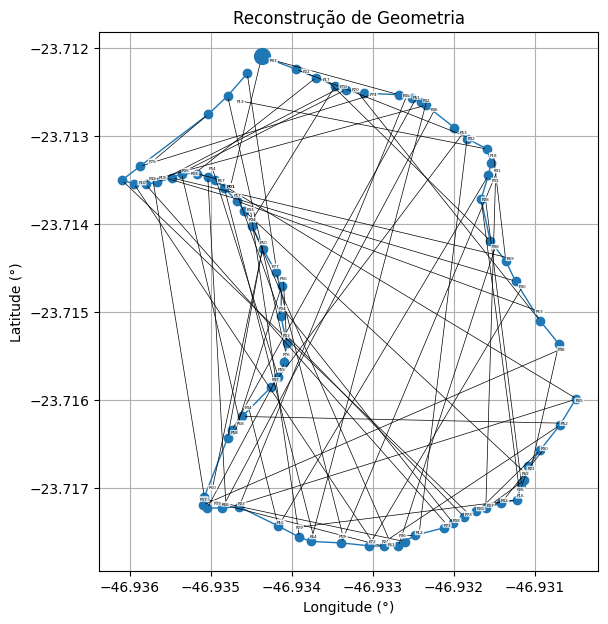

In [ ]:
# PLOTAGEM OS RESULTADOS SEM MAPA BASE

plt.figure(figsize=(7,7))
plt.plot(xv, yv, marker="o", linewidth=1)

texts = []

for i, (x, y) in enumerate(coords):
    label = f"P{i+1:02d}"

    if i == 0:
        plt.scatter(x, y, s=130, zorder=5)
        weight = "bold"
    else:
        weight = "normal"

    txt = plt.text(
        x, y, label,
        fontsize=3,
        fontweight=weight,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
        zorder=6
    )
    texts.append(txt)

adjust_text(
    texts,
    x=xv,
    y=yv,
    expand_points=(1.5, 1.5),
    expand_text=(1.4, 1.4),
    force_points=0.4,
    force_text=0.8,
    arrowprops=dict(arrowstyle="-", lw=0.5)
)

plt.gca().set_aspect(1 / k_lonlat)   # escala métrica igual nos dois eixos
plt.ticklabel_format(useOffset=False, style="plain")
plt.grid(True)
plt.title("Reconstrução de Geometria")
plt.xlabel("Longitude (°)")
plt.ylabel("Latitude (°)")
plt.show()

In [ ]:
# CÁLCULO DE ÁREA PELO MÉTODO ANALÍTICO DE GAUSS
coords_array = np.array(coords)

x = coords_array[:, 0]
y = coords_array[:, 1]

area_m2 = 0.5 * abs(
    np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))
)

area_ha = area_m2 / 10_000

print(f"Área (Shoelace): {area_m2:,.2f} m² ({area_ha:.4f} ha)")


# ÁREA GEODÉSICA (elipsoide GRS80 / SIRGAS 2000), para comparação
from pyproj import Geod
geod = Geod(ellps="GRS80")
area_geo, perim_geo = geod.polygon_area_perimeter(df["Lon"].values, df["Lat"].values)
area_geo = abs(area_geo)

print(f"Área (geodésica, GRS80): {area_geo:,.2f} m² ({area_geo/10_000:.4f} ha)")
print(f"Perímetro (geodésico):   {perim_geo:,.2f} m")
print(f"Diferença UTM - geodésica: {area_m2 - area_geo:+,.2f} m² ({(area_m2/area_geo - 1)*100:+.4f} %)")

In [ ]:
# PLOTAGEM COM MAPA BASE
m = plot_vertices_folium(coords, epsg_utm=EPSG_UTM)
m

In [ ]:
import simplekml

# EXPORTAÇÃO DA GEOMETRIA
# Usa diretamente as coordenadas geográficas do documento (sem ida e volta pela UTM).
# SIRGAS 2000 e WGS84 (realizações recentes) diferem em nível centimétrico;
# o pyproj trata a transformação entre ambos como nula.

kml = simplekml.Kml()

kml.document.name = "Vértices – Memorial Descritivo"
kml.document.description = (
    f"Coordenadas originais: geográficas em graus decimais ({CRS_GEOGRAFICO})\n"
    f"Datum declarado no documento: {datum_doc}\n"
    f"Projeção usada nos cálculos: {EPSG_UTM}\n\n"
    "Coordenadas gravadas no KML como lon/lat (EPSG:4326), "
    "exclusivamente para compatibilidade com o formato."
)

for i, ((x, y), lat, lon) in enumerate(zip(coords, df["Lat"], df["Lon"])):
    nome = f"P{i+1:02d}"

    pnt = kml.newpoint(
        name=nome,
        coords=[(lon, lat)]
    )

    pnt.description = (
        f"Vértice {nome}\n\n"
        f"Geográficas ({CRS_GEOGRAFICO}):\n"
        f"Lat = {lat:.9f}\n"
        f"Lon = {lon:.9f}\n\n"
        f"UTM ({EPSG_UTM}):\n"
        f"E = {x:.3f} m\n"
        f"N = {y:.3f} m"
    )

    pnt.style.iconstyle.scale = 0.9
    pnt.style.iconstyle.icon.href = (
        "http://maps.google.com/mapfiles/kml/shapes/placemark_circle.png"
    )

output_kml = f"/content/vertices_{EPSG_UTM.replace(':', '')}.kml"
kml.save(output_kml)

output_kml

3. GERAÇÃO DE MAPAS

In [ ]:
!pip install geopandas matplotlib contextily shapely matplotlib-scalebar cartopy

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar # Importação da barra de escala

def gerar_mapa_profissional(data_coords, crs, nome_imovel):
    # --- 1. CONFIGURAÇÃO DOS DADOS ---
    gdf = gpd.GeoDataFrame(index=[0], crs=crs, geometry=[Polygon(data_coords)])

    # --- 2. CRIAÇÃO DA FIGURA ---
    fig = plt.figure(figsize=(16, 9))
    gs = fig.add_gridspec(1, 2, width_ratios=[4, 1.2], wspace=0.05)

    ax_mapa = fig.add_subplot(gs[0])
    ax_info = fig.add_subplot(gs[1])
    ax_info.axis('off')

    # --- 3. DESENHO DO MAPA ---
    gdf.plot(ax=ax_mapa, facecolor='none', edgecolor='yellow', linewidth=2, zorder=10)


    ctx.add_basemap(ax_mapa, source=ctx.providers.Esri.WorldImagery, crs=gdf.crs)
    ctx.add_basemap(ax_mapa, source=ctx.providers.CartoDB.PositronOnlyLabels, crs=gdf.crs, zorder=11)

    # --- 4. INSERÇÃO DO NORTE ---
    # Colocamos o Norte no canto superior direito do mapa
    x_n, y_n, largura_n = 0.95, 0.95, 0.03
    ax_mapa.annotate('N', xy=(x_n, y_n), xytext=(x_n, y_n-0.08),
                     arrowprops=dict(facecolor='white', width=4, headwidth=12),
                     ha='center', va='center', fontsize=20, color='white',
                     fontweight='bold', xycoords='axes fraction')

    # --- 5. INSERÇÃO DA BARRA DE ESCALA ---
    # Como o CRS é UTM (metros), a escala 1:1 funciona perfeitamente
    scalebar = ScaleBar(1, units="m", location="lower left",
                        box_alpha=0.5, color="white", frameon=False)
    ax_mapa.add_artist(scalebar)

    # --- 6. CONFIGURAÇÕES ESTÉTICAS ---
    ax_mapa.grid(True, linestyle='--', alpha=0.3, color='white')
    ax_mapa.set_title(f"Mapa de Localização - {nome_imovel}", fontsize=12, fontweight='bold', pad=10)

    # --- 7. QUADRO DE INFORMAÇÕES (SIDEBAR) ---
    texto_tecnico = (
        f"QUADRO DE INFORMAÇÕES\n"
        f"{'-'*25}\n"
        f"IMÓVEL:\n{nome_imovel}\n\n"
        f"LOCALIZAÇÃO:\nCotia - SP\n\n"
        f"SGR:\n{crs}\n\n"
        f"IMAGEM BASE:\nEsri/DigitalGlobe\n"
        f"Mosaico: v.2024\n\n"
        f"NOTAS:\nPerímetro via OCR\nMultimodal."
    )

    ax_info.text(0.0, 0.95, texto_tecnico, transform=ax_info.transAxes,
                 fontsize=10, verticalalignment='top', family='monospace',
                 linespacing=1.5,
                 bbox=dict(facecolor='#f8f8f8', alpha=0.95, edgecolor='black', boxstyle='round,pad=0.8'))

    # Finalização
    plt.tight_layout()
    plt.savefig("mapa_com_escala_e_norte.pdf", dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
gerar_mapa_profissional(coords, EPSG_UTM, "")